MZI-based DEMUX

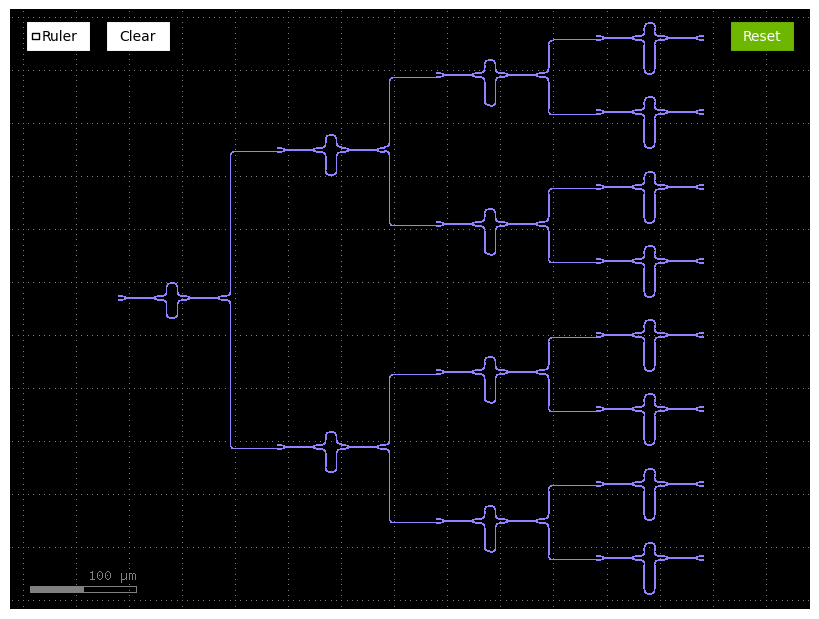

In [18]:
import gdsfactory as gf
from gdsfactory.typings import ComponentSpec
from typing import Dict, Optional, Tuple
import cspdk.si220.cband
from axiomatic.pic_helpers import plot_circuit

# Activate CSPDK
cspdk.si220.cband.activate_pdk()
pdk = gf.get_active_pdk()

def get_output_ports(parent: gf.ComponentReference) -> Tuple[str, str]:
    num_ports = len(parent.ports)
    return ("o3", "o4") if num_ports == 4 else ("o2", "o3")

def splitter_1xn(
    n_outputs: int,
    cell: ComponentSpec = "mzi",
    cell_settings: Optional[Dict[int, Dict]] = None,
    x_spacing: float = 90.0,
    y_spacing: float = 50.0,
) -> gf.Component:
    depth = int(np.log2(n_outputs))
    c = gf.Component()
    cell_refs = {}

    # Place cells in binary tree layout
    for level in range(depth + 1):
        num_cells = 2 ** level
        y_base = -(2 ** depth - 1) * y_spacing / 2
        stage_settings = cell_settings.get(level, {}) if cell_settings else {}

        for i in range(num_cells):
            x = level * x_spacing
            y = y_base + (2 ** (depth - level)) * y_spacing * (i + 0.5)
            ref = c << cell(**stage_settings)
            ref.name = f"cell_{level}_{i}"
            ref.move((x, y))
            cell_refs[(level, i)] = ref

    # Route ports from parents to children
    for level in range(depth):
        for i in range(2 ** level):
            parent = cell_refs[(level, i)]
            child_left = cell_refs[(level + 1, 2 * i)]
            child_right = cell_refs[(level + 1, 2 * i + 1)]

            out1, out2 = get_output_ports(parent)

            gf.routing.route_single(
                c, port1=parent.ports[out2], port2=child_left.ports["o1"],
                cross_section="strip", bend="bend_euler"
            )
            gf.routing.route_single(
                c, port1=parent.ports[out1], port2=child_right.ports["o1"],
                cross_section="strip", bend="bend_euler"
            )

    # Add input port
    c.add_port("in0", port=cell_refs[(0, 0)].ports["o1"])

    # Add output ports
    for i in range(2 ** depth):
        leaf = cell_refs[(depth, i)]
        c.add_port(f"out{i * 2}", port=leaf.ports["o2"])
        c.add_port(f"out{i * 2 + 1}", port=leaf.ports["o3"])

    return c

if __name__ == "__main__":
    def mzi_factory(delta_length=0):
        return pdk.get_component("mzi", delta_length=delta_length)

    # Example: delta lengths for each stage
    delta_lengths_by_stage = {
        0: {"delta_length": 10},
        1: {"delta_length": 20},
        2: {"delta_length": 30},
        3: {"delta_length": 40},
    }

    mzi_splitter = splitter_1xn(
        n_outputs=8,
        cell=mzi_factory,
        cell_settings=delta_lengths_by_stage,
        x_spacing=150,
        y_spacing=70
    )

    plot_circuit(mzi_splitter)
